# CCD Implementation

In [1]:
import numpy as np
import pandas as pd
from pyDOE3 import ccdesign, fullfact
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
# Step 1: Generate CCD with 'faced' or 'inscribed' design to avoid out-of-range values
#ccd_design = ccdesign(3, center=(4, 4), face='ccf')  # Or use face='cci' for inscribed
ccd_design = ccdesign(3, center=(4, 4), face='cci')
design_df = pd.DataFrame(ccd_design, columns=['start_flow_volume', 'feed_time', 'ramp_factor'])

len(design_df)

22

In [3]:
# Step 2: Define the corrected parameter ranges
param_ranges = {
    'start_flow_volume': (0.0001, 0.0009),
    'feed_time': (0.04,  0.2),
    'ramp_factor': (0.04, 0.1)
}

# Step 3: Map coded values to actual values for each parameter within bounds
for param, (low, high) in param_ranges.items():
    center = (low + high) / 2
    range_half = (high - low) / 2
    design_df[param] = center + design_df[param] * range_half

# Display the design matrix with values within bounds
print("Experimental design matrix with actual values (bounded):")
print(design_df)


Experimental design matrix with actual values (bounded):
    start_flow_volume  feed_time  ramp_factor
0            0.000281   0.076182     0.053568
1            0.000281   0.076182     0.086432
2            0.000281   0.163818     0.053568
3            0.000281   0.163818     0.086432
4            0.000719   0.076182     0.053568
5            0.000719   0.076182     0.086432
6            0.000719   0.163818     0.053568
7            0.000719   0.163818     0.086432
8            0.000500   0.120000     0.070000
9            0.000500   0.120000     0.070000
10           0.000500   0.120000     0.070000
11           0.000500   0.120000     0.070000
12           0.000100   0.120000     0.070000
13           0.000900   0.120000     0.070000
14           0.000500   0.040000     0.070000
15           0.000500   0.200000     0.070000
16           0.000500   0.120000     0.040000
17           0.000500   0.120000     0.100000
18           0.000500   0.120000     0.070000
19           0.000500  

# Perform all the experiments

In [4]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np

enzyme_activity = []

for index, row in design_df.iterrows():
    filename = f"doe_experiments/experiment_{index+1}.png"
    start_flow_volume = row['start_flow_volume']
    feed_interval = row['feed_time']
    ramp_factor = row['ramp_factor']

    print(f"------------- Experiment {index+1} ------------")
    print(f"Start flow volume {start_flow_volume}")
    print(f"Feed Interval {feed_interval}")
    print(f"Ramp Factor {ramp_factor}")
    

    initial_volume = start_flow_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor

    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate(S)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    

    enzyme_activity.append(D[i+1][2])
    print(f"Enzyme Activity : {D[i+1][2]}")
    print("________________________________________________")
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]


------------- Experiment 1 ------------
Start flow volume 0.0002809109769979336
Feed Interval 0.07618219539958673
Ramp Factor 0.05356832327484502
Enzyme Activity : 0.34027138126639794
________________________________________________
------------- Experiment 2 ------------
Start flow volume 0.0002809109769979336
Feed Interval 0.07618219539958673
Ramp Factor 0.08643167672515499
Enzyme Activity : 0.09498841937638351
________________________________________________
------------- Experiment 3 ------------
Start flow volume 0.0002809109769979336
Feed Interval 0.16381780460041329
Ramp Factor 0.05356832327484502
Enzyme Activity : 0.48665159876194586
________________________________________________
------------- Experiment 4 ------------
Start flow volume 0.0002809109769979336
Feed Interval 0.16381780460041329
Ramp Factor 0.08643167672515499
Enzyme Activity : 2.628057958774424
________________________________________________
------------- Experiment 5 ------------
Start flow volume 0.0007190890

In [5]:
design_df['enzyme_activity'] = enzyme_activity

In [6]:
# Fit the quadratic model
model = ols('enzyme_activity ~ start_flow_volume + feed_time + ramp_factor + \
             I(start_flow_volume**2) + I(feed_time**2) + I(ramp_factor**2) + \
             start_flow_volume:feed_time + start_flow_volume:ramp_factor + feed_time:ramp_factor',
            data=design_df).fit()

# Display model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        enzyme_activity   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     5.558
Date:                Sun, 09 Feb 2025   Prob (F-statistic):            0.00378
Time:                        20:55:44   Log-Likelihood:                -11.438
No. Observations:                  22   AIC:                             42.88
Df Residuals:                      12   BIC:                             53.79
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [7]:
import numpy as np
# Grid search within parameter ranges to find the maximum enzyme activity
best_enzyme_activity = -np.inf
best_settings = None


for vol in np.linspace(0.0001, 0.0009, 20):      # start_flow_volume range
    for time in np.linspace(0.04, 0.2, 20):     # feed_time range
        for ramp in np.linspace(0.04, 0.1, 20):  # ramp_factor range
            prediction = model.predict(pd.DataFrame({
                'start_flow_volume': [vol],
                'feed_time': [time],
                'ramp_factor': [ramp]
            }))[0]
            
            if prediction > best_enzyme_activity:
                best_enzyme_activity = prediction
                best_settings = (vol, time, ramp)

print("Optimal settings for maximum enzyme activity:")
print(f"Start flow volume: {best_settings[0]} L")
print(f"Feed time: {best_settings[1]} hours")
print(f"Ramp factor: {best_settings[2]}")
print(f"Predicted maximum enzyme activity: {best_enzyme_activity}")


Optimal settings for maximum enzyme activity:
Start flow volume: 0.0004789473684210526 L
Feed time: 0.14105263157894737 hours
Ramp factor: 0.07473684210526316
Predicted maximum enzyme activity: 2.2864785243220127


 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  2.8648062738353275


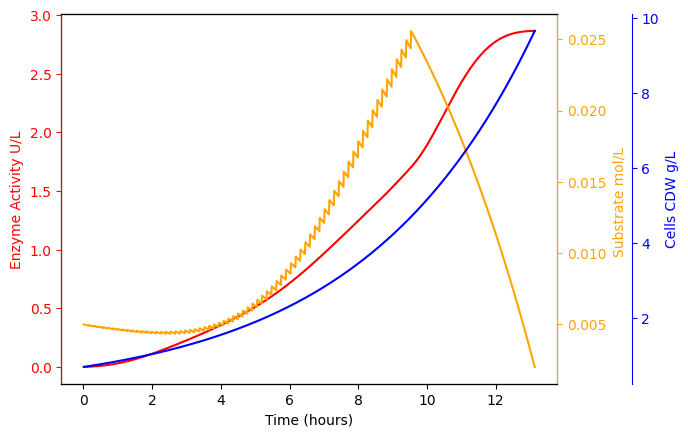

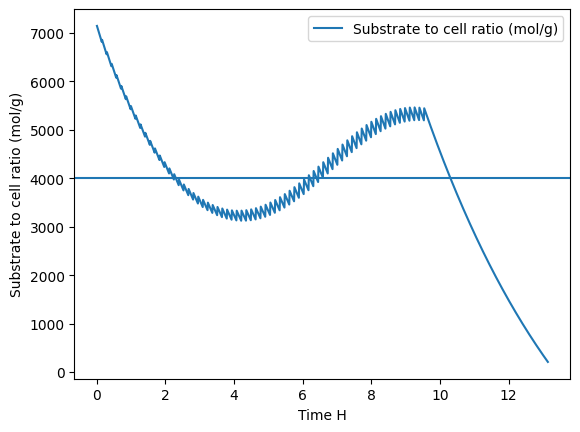

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

initial_volume = best_settings[0]
flow_volume = initial_volume
ramp_rate = best_settings[2] 
transfer_interval = best_settings[1]

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  transfer_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO * 1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = (S/X) * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
#fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e6)
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()